In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load the mission launches data
df = pd.read_csv('mission_launches.csv')

# Quick look to confirm it loaded
print(f"Shape: {df.shape}")
df.head()

Shape: (4324, 9)


,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


In [4]:
df_clean = df.copy()

# Fix the date column
df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='mixed', utc=True)

# Fix the Price column
df_clean['Price'] = pd.to_numeric(df_clean['Price'], errors='coerce')

print("Data cleaned! Ready to analyze.")
print(f"Rows: {len(df_clean)}")

Data cleaned! Ready to analyze.
Rows: 4324


In [8]:
# Business Question 1: Which organizations are most successful?
# Success rate by organization (top 10 orgs)
top_orgs = df_clean['Organisation'].value_counts().head(10).index

# Filter to top 10 orgs
top_org_data = df_clean[df_clean['Organisation'].isin(top_orgs)]

# Success rate per org
success_rate = top_org_data.groupby('Organisation')['Mission_Status'].apply(
    lambda x: (x == 'Success').sum() / len(x) * 100
).round(1).sort_values(ascending=False)

print("Success Rate by Organization (%):")
print(success_rate)

Success Rate by Organization (%):
Organisation
ULA                 99.3
Arianespace         96.4
Boeing              96.3
VKS RF              93.5
CASC                92.0
NASA                91.6
RVSN USSR           90.8
Martin Marietta     87.7
General Dynamics    80.9
US Air Force        80.1
Name: Mission_Status, dtype: float64


In [9]:
# Business Question 2: How have launches changed over decades?
# Add decade column
df_clean['Decade'] = (df_clean['Date'].dt.year // 10 * 10).astype(str) + 's'

# Count by decade
decade_launches = df_clean.groupby('Decade').size()
print("\nLaunches by Decade:")
print(decade_launches)


Launches by Decade:
Decade
1950s      51
1960s     774
1970s    1012
1980s     631
1990s     642
2000s     475
2010s     676
2020s      63
dtype: int64


In [10]:
# Business Question 3: Are launches getting cheaper?
# Average price by year (only where price exists)
price_by_year = df_clean.groupby(df_clean['Date'].dt.year)['Price'].mean().dropna()
print("\nAverage Launch Price by Year (millions USD):")
print(price_by_year.tail(10))


Average Launch Price by Year (millions USD):
Date
2011    146.596552
2012    122.292000
2013     90.551515
2014    102.551220
2015     91.548718
2016     79.457344
2017     69.491061
2018     64.749773
2019     59.609726
2020     56.650192
Name: Price, dtype: float64


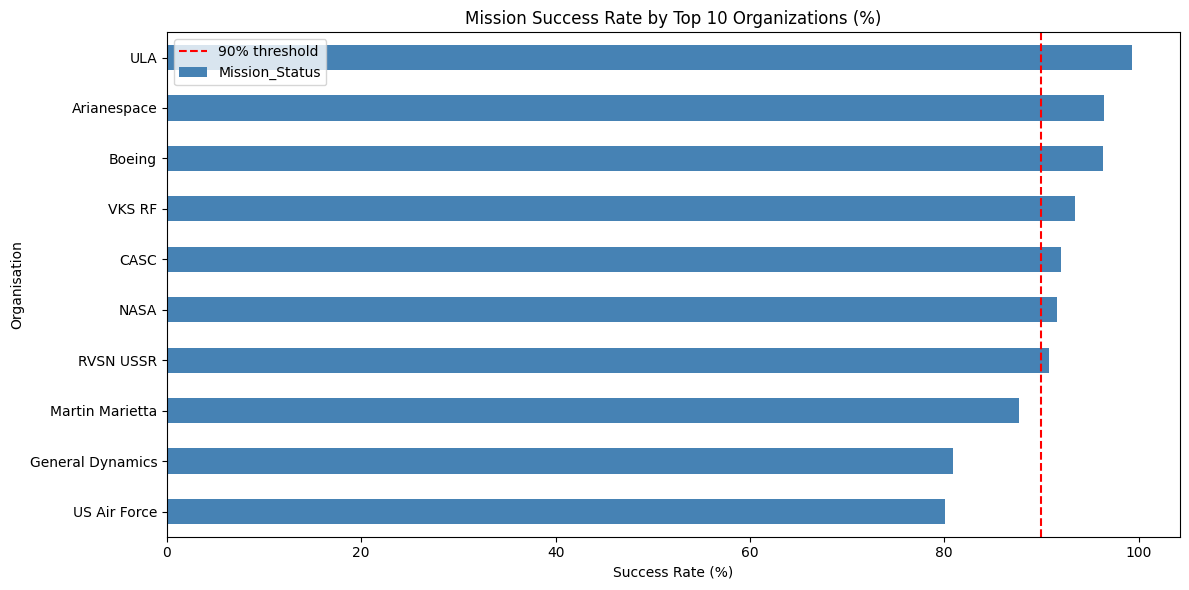

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
success_rate.sort_values().plot(kind='barh', color='steelblue')
plt.title('Mission Success Rate by Top 10 Organizations (%)')
plt.xlabel('Success Rate (%)')
plt.axvline(x=90, color='red', linestyle='--', label='90% threshold')
plt.legend()
plt.tight_layout()
plt.savefig('visualizations/success_rate_by_org.png', dpi=300, bbox_inches='tight')
plt.show()

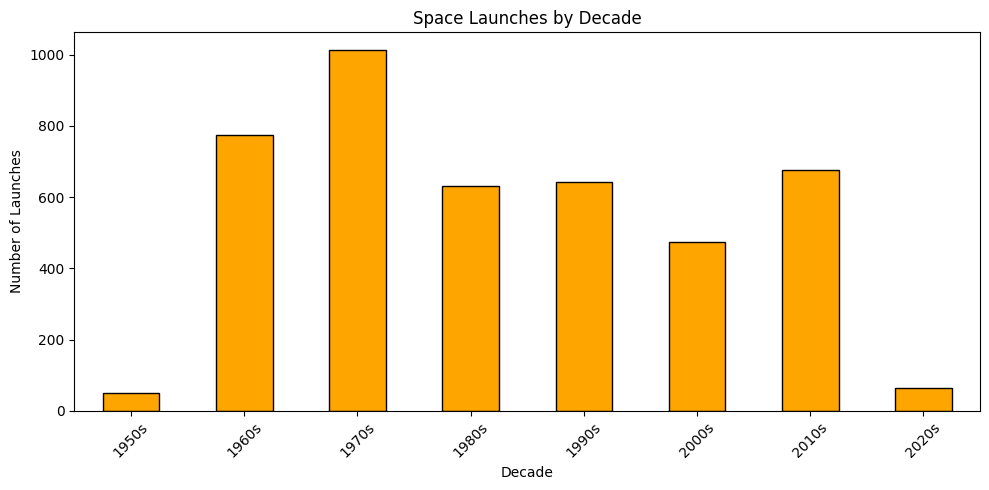

In [16]:
plt.figure(figsize=(10, 5))
decade_launches.plot(kind='bar', color='orange', edgecolor='black')
plt.title('Space Launches by Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Launches')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('visualizations/launches_by_decade.png', dpi=300, bbox_inches='tight')
plt.show()

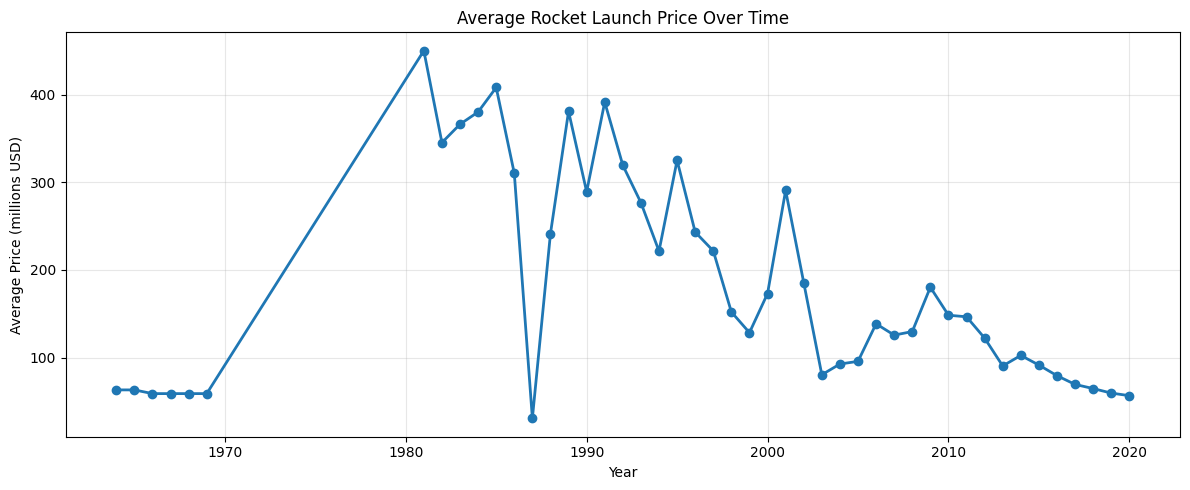

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(price_by_year.index, price_by_year.values, marker='o', linewidth=2)
plt.title('Average Rocket Launch Price Over Time')
plt.xlabel('Year')
plt.ylabel('Average Price (millions USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('visualizations/price_trend_over_time.png', dpi=300, bbox_inches='tight')
plt.show()